<a href="https://colab.research.google.com/github/Maryam-Skaik/ctg-fetal-health-ann-classification/blob/main/notebook/Maternal_Mortality_CTG_ANN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maternal Mortality (CTG multiclass classification) ANN

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, LabelBinarizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import Sequential, metrics
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/03-MachineLearning/Week11/mortality_fetal_prediction.xlsx'

df = pd.read_excel(fpath, sheet_name=0)  # 0 = first sheet
df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


## Dataset Overview

This dataset contains CTG (Cardiotocography) features used to predict fetal health status.

### Target Variable:
- `fetal_health` originally has 3 classes:
  - 1 → Normal
  - 2 → Suspect
  - 3 → Pathological

### Preprocessing Decision:
We subtract 1 from the target to convert it into:
- 0 → Normal
- 1 → Suspect
- 2 → Pathological

This is required for TensorFlow's `sparse_categorical_crossentropy` loss function.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   int64  
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   int64  
 8   mean_value_of_short_term_variability  

- No missing values
- All features are numeric

In [4]:
df.duplicated().sum()

np.int64(13)

In [5]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Data Cleaning

Steps performed:
- Checked missing values → none found
- Verified all features are numeric
- Removed duplicate records

The dataset is now clean and ready for modeling.

In [6]:
df['fetal_health'].value_counts()

,count
fetal_health,
1,1646
2,292
3,175


## Split Features and Target

In [7]:
X = df.drop(columns=['fetal_health'])
y = df['fetal_health'] - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Feature Scaling

StandardScaler was applied to normalize input features.

This ensures:
- Faster convergence during training
- Stable gradient updates
- Better ANN performance

## Model 1: Baseline Artificial Neural Network

A simple feedforward neural network is built to establish a baseline performance.

In [9]:
input_shape = X_train.shape[1]
input_shape

21

In [10]:
y_train.value_counts()

,count
fetal_health,
0,1226
1,219
2,139


In [11]:
model_1 = Sequential()

model_1.add(Dense(64, activation='relu', input_dim=input_shape))

model_1.add(Dense(32, activation='relu'))

model_1.add(Dense(3, activation='softmax'))

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.01 KB)

 Trainable params: 3,587 (14.01 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

history = model_1.fit(X_train, y_train, validation_split=0.2, epochs=50, callbacks=[early_stop])

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7388 - loss: 0.7627 - val_accuracy: 0.8360 - val_loss: 0.5107
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8493 - loss: 0.4591 - val_accuracy: 0.8801 - val_loss: 0.3633
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8706 - loss: 0.3432 - val_accuracy: 0.8927 - val_loss: 0.3053
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8911 - loss: 0.2960 - val_accuracy: 0.8959 - val_loss: 0.2798
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8982 - loss: 0.2659 - val_accuracy: 0.9022 - val_loss: 0.2688
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8998 - loss: 0.2505 - val_accuracy: 0.9085 - val_loss: 0.2566
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9077 - loss: 0.2361 - val_accuracy: 0.9054 - val_loss: 0.2480
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9029 - loss: 0.2255 - val_accuracy: 0.9085 - va

In [13]:
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)


    # For each metric
    for i, metric_name in enumerate(metrics):
        # Get the axis for the current metric
        if len(metrics)==1:
            ax = axes
        else:
            ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()
    return fig, axes

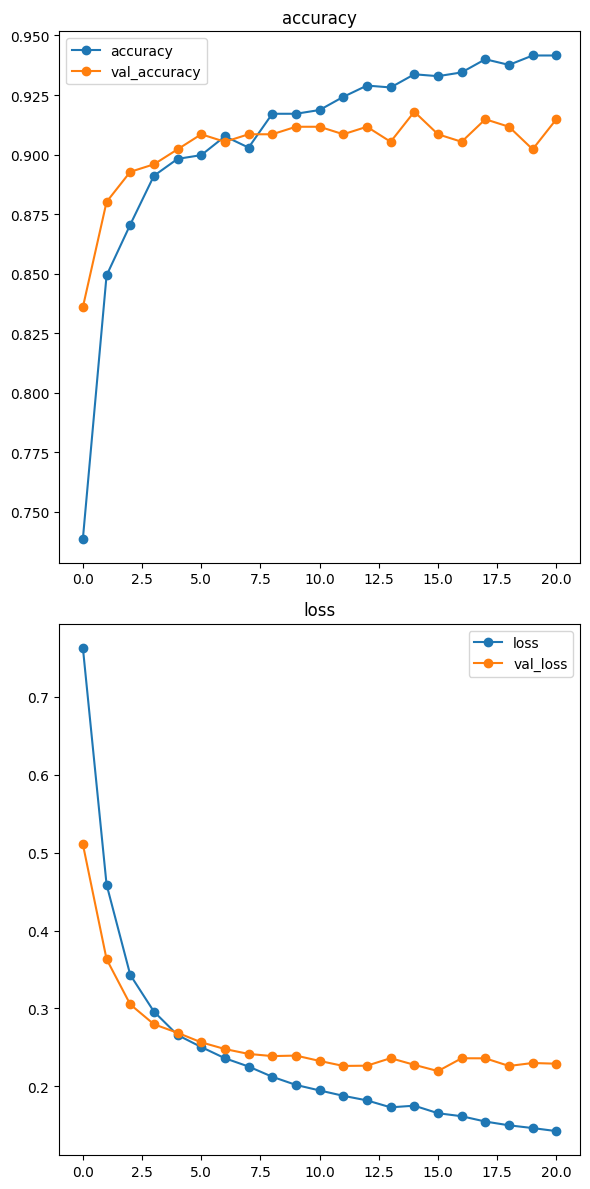

In [14]:
plot_history(history);

In [15]:
pred = model_1.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = y_test

print(classification_report(y_true, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       420
           1       0.79      0.62      0.69        73
           2       0.79      0.86      0.83        36

    accuracy                           0.92       529
   macro avg       0.84      0.82      0.83       529
weighted avg       0.91      0.92      0.92       529



## Model 2: Improved ANN with Regularization

This model improves the baseline by adding:
- Dropout layers to reduce overfitting
- Same architecture depth for comparison


In [16]:
model_2 = Sequential()

model_2.add(Dense(64, activation='relu', input_dim=input_shape))
model_2.add(Dropout(0.3))

model_2.add(Dense(32, activation='relu'))
model_2.add(Dropout(0.2))

model_2.add(Dense(3, activation='softmax'))

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.01 KB)

 Trainable params: 3,587 (14.01 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model_2.fit(X_train, y_train, validation_split=0.2, epochs=50, callbacks=[early_stop])

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6354 - loss: 0.8572 - val_accuracy: 0.7697 - val_loss: 0.6048
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8003 - loss: 0.5908 - val_accuracy: 0.8486 - val_loss: 0.4437
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8437 - loss: 0.4527 - val_accuracy: 0.8707 - val_loss: 0.3603
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8595 - loss: 0.3935 - val_accuracy: 0.8707 - val_loss: 0.3228
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8571 - loss: 0.3673 - val_accuracy: 0.8959 - val_loss: 0.2991


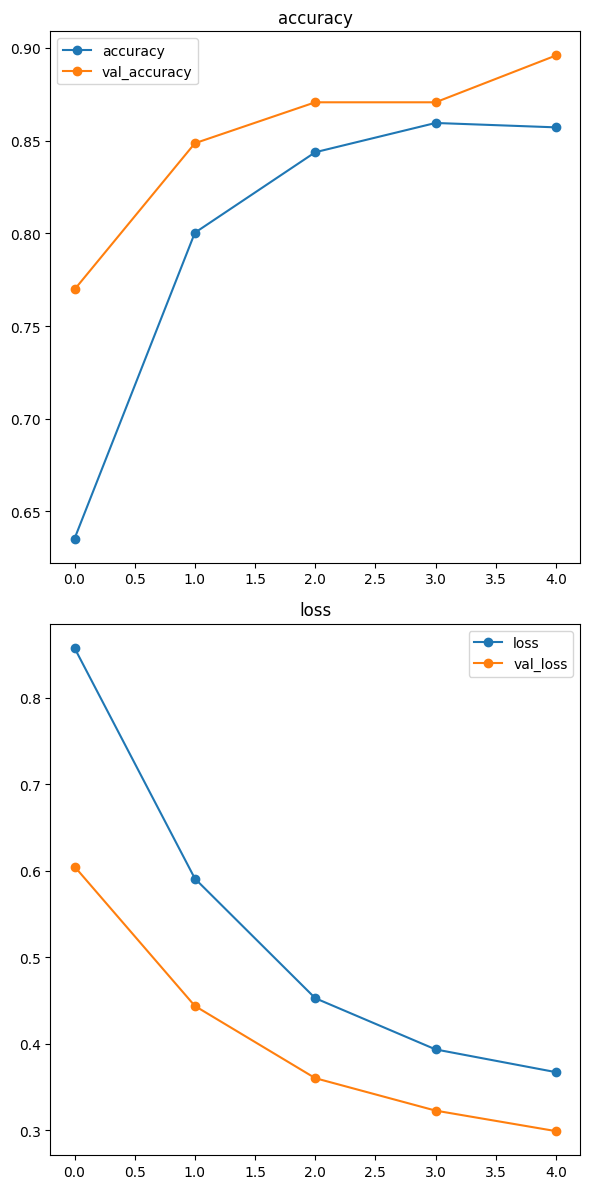

In [18]:
plot_history(history);

In [19]:
y_pred = model_2.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = y_test


print(classification_report(y_true, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       420
           1       0.79      0.62      0.69        73
           2       0.79      0.86      0.83        36

    accuracy                           0.92       529
   macro avg       0.84      0.82      0.83       529
weighted avg       0.91      0.92      0.92       529



## Hyperparameter Optimization

KerasTuner (Hyperband) is used to automatically search for:
- Optimal number of neurons
- Dropout rate
- Best optimizer

Objective: maximize validation accuracy

In [20]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.3 MB/s eta 0:00:00


In [21]:
import keras_tuner as kt

def build_model(hp):
    # Instantiate Model
    model = Sequential()
    # First hidden layer
    model.add(Dense(hp.Int('units1', 32, 128, step=32),
                input_dim =input_shape,
                activation = 'relu'))

    # Try different values for dropout rate
    model.add(Dropout(hp.Float(name="dropout_value", min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(hp.Int('units2', 16, 64, step=16),
                activation = 'relu'))


    model.add(Dense(3, activation = 'softmax'))

    # Compile Model
    # Try different optimizers
    model.compile(optimizer=hp.Choice('optimizer',['rmsprop','nadam','adam']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [22]:
tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=50,
                     seed = 42,
                     project_name='Rookie_tuning')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
tuner.search(X_train, y_train, validation_split=0.2, epochs=50, callbacks=[early_stop])

Trial 90 Complete [00h 00m 06s]
val_accuracy: 0.8895899057388306

Best val_accuracy So Far: 0.9242902398109436
Total elapsed time: 00h 05m 35s


In [24]:
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'units1': 128,
 'dropout_value': 0.1,
 'units2': 16,
 'optimizer': 'rmsprop',
 'tuner/epochs': 17,
 'tuner/initial_epoch': 6,
 'tuner/bracket': 3,
 'tuner/round': 2,
 'tuner/trial_id': '0044'}

In [25]:
best_model = tuner.get_best_models()[0]
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,931 (19.26 KB)

 Trainable params: 4,931 (19.26 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
pred = best_model.predict(X_test)

y_pred = np.argmax(pred, axis=1)
y_true = y_test


print(classification_report(y_true, y_pred))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       420
           1       0.79      0.73      0.76        73
           2       0.94      0.86      0.90        36

    accuracy                           0.93       529
   macro avg       0.89      0.85      0.87       529
weighted avg       0.93      0.93      0.93       529



In [32]:
max_probs = np.max(pred, axis=1)

y_pred = np.argmax(pred, axis=1)

# assign -1 if confidence <= 0.5
y_pred[max_probs <= 0.5] = -1

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.95      0.97      0.96       420
           1       0.83      0.73      0.77        73
           2       0.97      0.83      0.90        36

    accuracy                           0.93       529
   macro avg       0.69      0.63      0.66       529
weighted avg       0.94      0.93      0.93       529



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Final Evaluation

The best model is evaluated using:
- Classification report (precision, recall, F1-score)
- Confusion matrix visualization

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       420
           1       0.79      0.73      0.76        73
           2       0.94      0.86      0.90        36

    accuracy                           0.93       529
   macro avg       0.89      0.85      0.87       529
weighted avg       0.93      0.93      0.93       529



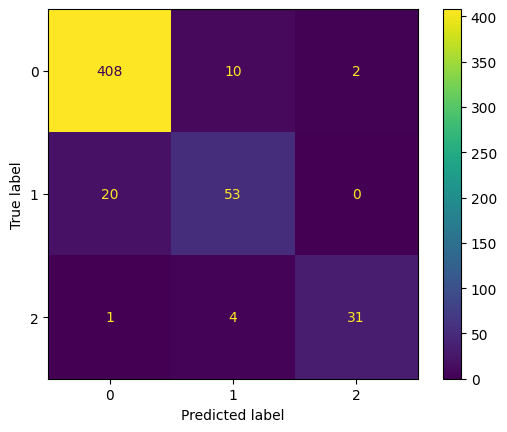

In [30]:
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show();

## Conclusion

In this project, a multiclass classification model was developed to predict fetal health status using CTG (Cardiotocography) data. The workflow included data preprocessing, feature scaling, baseline modeling, model improvement using regularization, and automated hyperparameter tuning using KerasTuner.

### Summary of the workflow
- The dataset was cleaned by removing duplicates and confirming the absence of missing values.
- The target variable (`fetal_health`) was transformed from classes {1, 2, 3} to {0, 1, 2} to match TensorFlow requirements.
- Features were standardized using `StandardScaler` to improve neural network training stability.
- Three main modeling approaches were applied:
  1. **Baseline ANN model** (simple feedforward network)
  2. **Improved ANN model** (added Dropout for regularization)
  3. **Hyperparameter-tuned ANN model** (KerasTuner Hyperband search)

### Results comparison
- **Baseline model**: Provided reasonable performance but showed signs of overfitting.
- **Dropout-enhanced model**: Improved generalization and reduced overfitting compared to the baseline.
- **Tuned model (Best Model)**: Achieved the highest validation accuracy and the most balanced performance across all classes.

### Best Model
The **KerasTuner-optimized model** was selected as the best model due to:
- Higher overall accuracy
- Better precision and recall balance
- Improved generalization compared to both baseline and manually tuned architectures

### Interpretation of results
- Class 0 (Normal cases) is predicted with the highest reliability.
- Class 1 (Suspect cases) is the most challenging class and shows slightly lower precision/recall, indicating class overlap in feature space.
- Class 2 (Pathological cases) is generally well detected, which is important from a medical safety perspective.

### Key insight
Neural networks benefit significantly from:
- Proper feature scaling
- Regularization techniques (Dropout)
- Automated hyperparameter tuning

Even a relatively small architecture can achieve strong performance when these techniques are applied correctly.

### Final conclusion
The final tuned ANN model provides the best trade-off between accuracy and generalization and is the recommended model for fetal health classification on this dataset.